# 03. MODEL TRAINING:
    • Model1/ #(ResNet18)    
    • Model2/ #(ResNet18 w/ Temporal Vector)
    • Model3/ #(ResNet18 + CustomLoss)
    • Model4/ #(ResNet18 w/ Temporal Vector + CustomLoss)


In [1]:
import subprocess
import sys
import os

def get_repo_root():
    return subprocess.check_output(['git', 'rev-parse', '--show-toplevel']).decode('utf-8').strip()
repo_root = get_repo_root()
print(repo_root)

src_path = os.path.join(repo_root, 'src')
# Add src_path to sys.path if not already present
if src_path not in sys.path:
    sys.path.insert(0, src_path)

/Users/geoffreyfadera/Documents/USD Stuff/AAI-590/Wild-Scan


In [2]:
import boto3

session = boto3.Session(profile_name='jop-training-sso')

sts = session.client('sts')
identity = sts.get_caller_identity()
role = identity['Arn']
s3_client = session.client('s3')
display(role)

#display(role)
bucket_name = "aai-590-tmp2"
train_val_dir = "data_split/train_val"
# S3 URIs for your CSV files
s3_train = f's3://{bucket_name}/{train_val_dir}/train-meta.csv'
s3_val =  f's3://{bucket_name}/{train_val_dir}/val-meta.csv'
s3_label2idx = f's3://{bucket_name}/{train_val_dir}/label_mapping.json'

'arn:aws:sts::324183265896:assumed-role/AWSReservedSSO_aai-590-training-permission_a601dd5621a14868/geoffrey@aai-590'

In [3]:
import torch
print(torch.backends.mps.is_available())  # Should be True
print(torch.backends.mps.is_built())      # Should be True
import train as custom_train

True
True


## Configure Model Training Related Parameters

In [4]:
MODELS_DICT = {
    0: {'name' : 'BuiltFromScratch', 'base' : 'None', 'use_custom_loss' : False},
    1: {'name' : 'Resnet18_ft', 'base' : 'AnimalClassifier', 'use_custom_loss' : False},
    2: {'name' : 'Resnet18_ft_withTemporalVector', 'base' : 'AnimalTemporalClassifier', 'use_custom_loss' : False},
    3: {'name' : 'Resnet18_ft_customLoss','base' : 'AnimalClassifier', 'use_custom_loss' : True},
    4: {'name' : 'Resnet18_ft_withTemporalVector_customLoss','base' : 'AnimalTemporalClassifier','use_custom_loss' : True}
}

In [8]:
# Model 1: Resnet18, default loss, no temporal vector 

#=== Model Id Settings========
MODEL_NUMBER = 1
MODEL_NAME = MODELS_DICT[MODEL_NUMBER]['name']
MODEL_BASE = MODELS_DICT[MODEL_NUMBER]['base']
LOCAL_MODEL_OUTPUT_DIR = f'./models/model{MODEL_NUMBER}'
s3_output_location = f"s3://{bucket_name}/{MODEL_NAME}/output"

#=== Training Settings======
learning_rate = 1e-4 # lower values are better for fine-tuning tasks
epochs = 5  # Set the number of epochs as needed
batch_size = 32  # Set the batch size as needed
USE_CUSTOM_LOSS = MODELS_DICT[MODEL_NUMBER]['use_custom_loss']

In [9]:
MODEL_NAME, MODEL_BASE, USE_CUSTOM_LOSS

('Resnet18_ft', 'AnimalClassifier', False)

In [ ]:
import importlib
importlib.reload(custom_train) 

In [10]:
# prepare input parameters for training
input_params = [    
    "--train_csv", s3_train,
    "--val_csv", s3_val,
    "--label2idx_json", s3_label2idx,
    "--model_dir", s3_output_location,
    "--lr", str(learning_rate),
    "--batch_size", str(batch_size),   
    "--epochs", str(epochs),
    "--custom_model", MODEL_BASE,
    "--use_custom_loss", USE_CUSTOM_LOSS,
    "--local_model_dir", LOCAL_MODEL_OUTPUT_DIR,
    "--session_profile_name", 'jop-training-sso',
]
args = custom_train.parse_args(input_params)


In [11]:
# run training script
custom_train.train(args)

DEBUG INFO: DEVICE:  mps
DEBUG INFO: AWS STS Identity:  {'UserId': 'AROAUW6WUCJUFVCJU3SRA:geoffrey@aai-590', 'Account': '324183265896', 'Arn': 'arn:aws:sts::324183265896:assumed-role/AWSReservedSSO_aai-590-training-permission_a601dd5621a14868/geoffrey@aai-590', 'ResponseMetadata': {'RequestId': '1900c26d-77c2-41d1-9de3-6a95a960f732', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': '1900c26d-77c2-41d1-9de3-6a95a960f732', 'content-type': 'text/xml', 'content-length': '498', 'date': 'Tue, 29 Jul 2025 05:34:57 GMT'}, 'RetryAttempts': 0}}
DEBUG CHECK: S3 CLIENT DOWNLOAD: (tmp_label_mapping.json) OK
DEBUG CHECK Label2Idx json length:  17
DEBUG input csv s3: aai-590-tmp2, data_split/train_val, train-meta.csv
DEBUG INFO: self.df.shape = (22003, 15)
DEBUG INFO: self.fs OK
DEBUG label mapping json s3: aai-590-tmp2, data_split/train_val, label_mapping.json
DEBUG INFO: self.label2idx = {'car': 0, 'coyote': 1, 'deer': 2, 'bobcat': 3, 'dog': 4, 'skunk': 5, 'empty': 6, 'cat': 7, 'opossum':

/opt/miniconda3/envs/pytorch_base/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/envs/pytorch_base/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


LOSS FUNCTION: Cross Entropy

===========EPOCH 1=================
TRAINING...
--Learning Rate: 0.0001


/opt/miniconda3/envs/pytorch_base/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


--processing batch 687/688
--done! time elapsed: 506.89 s
--train_acc: 0.86
--train_loss: 0.46, train_ce_loss: 0.00
VALIDATION started....
--done! time elapsed: 225.34 s
--val_acc: 0.84
--val_loss: 0.02, val_ce_loss: 0.00

===========EPOCH 2=================
TRAINING...
--Learning Rate: 0.0001
--processing batch 687/688
--done! time elapsed: 501.64 s
--train_acc: 0.96
--train_loss: 0.14, train_ce_loss: 0.00
VALIDATION started....
--done! time elapsed: 223.24 s
--val_acc: 0.86
--val_loss: 0.02, val_ce_loss: 0.00

===========EPOCH 3=================
TRAINING...
--Learning Rate: 2e-05
--processing batch 687/688
--done! time elapsed: 504.35 s
--train_acc: 0.99
--train_loss: 0.05, train_ce_loss: 0.00
VALIDATION started....
--done! time elapsed: 228.46 s
--val_acc: 0.87
--val_loss: 0.01, val_ce_loss: 0.00

===========EPOCH 4=================
TRAINING...
--Learning Rate: 2e-05
--processing batch 687/688
--done! time elapsed: 504.82 s
--train_acc: 1.00
--train_loss: 0.02, train_ce_loss: 0.00
V

### MODEL #2

In [12]:
# Model 2: Resnet18, default loss, with temporal vector 

#=== Model Id Settings========
MODEL_NUMBER = 2
MODEL_NAME = MODELS_DICT[MODEL_NUMBER]['name']
MODEL_BASE = MODELS_DICT[MODEL_NUMBER]['base']
LOCAL_MODEL_OUTPUT_DIR = f'./models/model{MODEL_NUMBER}'
s3_output_location = f"s3://{bucket_name}/{MODEL_NAME}/output"

#=== Training Settings======
learning_rate = 1e-4 # lower values are better for fine-tuning tasks
epochs = 5  # Set the number of epochs as needed
batch_size = 32  # Set the batch size as needed
USE_CUSTOM_LOSS = MODELS_DICT[MODEL_NUMBER]['use_custom_loss']

MODEL_NAME, MODEL_BASE, USE_CUSTOM_LOSS

('Resnet18_ft_withTemporalVector', 'AnimalTemporalClassifier', False)

In [13]:
# prepare input parameters for training
input_params = [    
    "--train_csv", s3_train,
    "--val_csv", s3_val,
    "--label2idx_json", s3_label2idx,
    "--model_dir", s3_output_location,
    "--lr", str(learning_rate),
    "--batch_size", str(batch_size),   
    "--epochs", str(epochs),
    "--custom_model", MODEL_BASE,
    "--use_custom_loss", USE_CUSTOM_LOSS,
    "--local_model_dir", LOCAL_MODEL_OUTPUT_DIR,
    "--session_profile_name", 'jop-training-sso',
]
args = custom_train.parse_args(input_params)

In [14]:
# run training script
custom_train.train(args)

DEBUG INFO: DEVICE:  mps
DEBUG INFO: AWS STS Identity:  {'UserId': 'AROAUW6WUCJUFVCJU3SRA:geoffrey@aai-590', 'Account': '324183265896', 'Arn': 'arn:aws:sts::324183265896:assumed-role/AWSReservedSSO_aai-590-training-permission_a601dd5621a14868/geoffrey@aai-590', 'ResponseMetadata': {'RequestId': 'd6e32152-ee76-4a35-bc15-4af38f31a174', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': 'd6e32152-ee76-4a35-bc15-4af38f31a174', 'content-type': 'text/xml', 'content-length': '498', 'date': 'Tue, 29 Jul 2025 06:49:46 GMT'}, 'RetryAttempts': 0}}
DEBUG CHECK: S3 CLIENT DOWNLOAD: (tmp_label_mapping.json) OK
DEBUG CHECK Label2Idx json length:  17
DEBUG input csv s3: aai-590-tmp2, data_split/train_val, train-meta.csv
DEBUG INFO: self.df.shape = (22003, 15)
DEBUG INFO: self.fs OK
DEBUG label mapping json s3: aai-590-tmp2, data_split/train_val, label_mapping.json
DEBUG INFO: self.label2idx = {'car': 0, 'coyote': 1, 'deer': 2, 'bobcat': 3, 'dog': 4, 'skunk': 5, 'empty': 6, 'cat': 7, 'opossum':

/opt/miniconda3/envs/pytorch_base/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/envs/pytorch_base/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


LOSS FUNCTION: Cross Entropy

===========EPOCH 1=================
TRAINING...
--Learning Rate: 0.0001


/opt/miniconda3/envs/pytorch_base/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


--processing batch 687/688
--done! time elapsed: 502.24 s
--train_acc: 0.81
--train_loss: 0.67, train_ce_loss: 0.00
VALIDATION started....
--done! time elapsed: 224.11 s
--val_acc: 0.82
--val_loss: 0.02, val_ce_loss: 0.00

===========EPOCH 2=================
TRAINING...
--Learning Rate: 0.0001
--processing batch 687/688
--done! time elapsed: 521.78 s
--train_acc: 0.95
--train_loss: 0.17, train_ce_loss: 0.00
VALIDATION started....
--done! time elapsed: 229.49 s
--val_acc: 0.83
--val_loss: 0.02, val_ce_loss: 0.00

===========EPOCH 3=================
TRAINING...
--Learning Rate: 2e-05
--processing batch 687/688
--done! time elapsed: 514.48 s
--train_acc: 0.98
--train_loss: 0.06, train_ce_loss: 0.00
VALIDATION started....
--done! time elapsed: 232.07 s
--val_acc: 0.88
--val_loss: 0.01, val_ce_loss: 0.00

===========EPOCH 4=================
TRAINING...
--Learning Rate: 2e-05
--processing batch 687/688
--done! time elapsed: 516.12 s
--train_acc: 0.99
--train_loss: 0.04, train_ce_loss: 0.00
V

### MODEL #3

In [15]:
# Model 3: Resnet18, custom loss, with temporal vector 

#=== Model Id Settings========
MODEL_NUMBER = 3
MODEL_NAME = MODELS_DICT[MODEL_NUMBER]['name']
MODEL_BASE = MODELS_DICT[MODEL_NUMBER]['base']
LOCAL_MODEL_OUTPUT_DIR = f'./models/model{MODEL_NUMBER}'
s3_output_location = f"s3://{bucket_name}/{MODEL_NAME}/output"

#=== Training Settings======
learning_rate = 1e-4 # lower values are better for fine-tuning tasks
epochs = 5  # Set the number of epochs as needed
batch_size = 32  # Set the batch size as needed
USE_CUSTOM_LOSS = MODELS_DICT[MODEL_NUMBER]['use_custom_loss']

MODEL_NAME, MODEL_BASE, USE_CUSTOM_LOSS

('Resnet18_ft_customLoss', 'AnimalClassifier', True)

In [17]:
# prepare input parameters for training
input_params = [    
    "--train_csv", s3_train,
    "--val_csv", s3_val,
    "--label2idx_json", s3_label2idx,
    "--model_dir", s3_output_location,
    "--lr", str(learning_rate),
    "--batch_size", str(batch_size),   
    "--epochs", str(epochs),
    "--custom_model", MODEL_BASE,
    "--use_custom_loss", str(USE_CUSTOM_LOSS),
    "--local_model_dir", LOCAL_MODEL_OUTPUT_DIR,
    "--session_profile_name", 'jop-training-sso',
]
args = custom_train.parse_args(input_params)

In [18]:
# run training script
custom_train.train(args)

DEBUG INFO: DEVICE:  mps
DEBUG INFO: AWS STS Identity:  {'UserId': 'AROAUW6WUCJUFVCJU3SRA:geoffrey@aai-590', 'Account': '324183265896', 'Arn': 'arn:aws:sts::324183265896:assumed-role/AWSReservedSSO_aai-590-training-permission_a601dd5621a14868/geoffrey@aai-590', 'ResponseMetadata': {'RequestId': '000e6f67-468f-438d-9daf-7d073ee44056', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': '000e6f67-468f-438d-9daf-7d073ee44056', 'content-type': 'text/xml', 'content-length': '498', 'date': 'Tue, 29 Jul 2025 07:56:40 GMT'}, 'RetryAttempts': 0}}
DEBUG CHECK: S3 CLIENT DOWNLOAD: (tmp_label_mapping.json) OK
DEBUG CHECK Label2Idx json length:  17
DEBUG input csv s3: aai-590-tmp2, data_split/train_val, train-meta.csv
DEBUG INFO: self.df.shape = (22003, 15)
DEBUG INFO: self.fs OK
DEBUG label mapping json s3: aai-590-tmp2, data_split/train_val, label_mapping.json
DEBUG INFO: self.label2idx = {'car': 0, 'coyote': 1, 'deer': 2, 'bobcat': 3, 'dog': 4, 'skunk': 5, 'empty': 6, 'cat': 7, 'opossum':

/opt/miniconda3/envs/pytorch_base/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/envs/pytorch_base/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


LOSS FUNCTION: Custom Loss with Margin

===========EPOCH 1=================
TRAINING...
--Loss Margin Lambda: 0.1
--Loss Margin Format: probs
--Train Loss Reduction: mean
--Learning Rate: 0.0001


/opt/miniconda3/envs/pytorch_base/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


--processing batch 687/688
--done! time elapsed: 511.99 s
--train_acc: 0.87
--train_loss: 0.37, train_ce_loss: 0.45
VALIDATION started....
--Val Loss Reduction: none
--done! time elapsed: 230.56 s
--val_acc: 0.82
--val_loss: 0.52, val_ce_loss: 0.60

===========EPOCH 2=================
TRAINING...
--Loss Margin Lambda: 0.1
--Loss Margin Format: probs
--Train Loss Reduction: mean
--Learning Rate: 0.0001
--processing batch 687/688
--done! time elapsed: 515.40 s
--train_acc: 0.96
--train_loss: 0.05, train_ce_loss: 0.14
VALIDATION started....
--Val Loss Reduction: none
--done! time elapsed: 226.81 s
--val_acc: 0.85
--val_loss: 0.46, val_ce_loss: 0.54

===========EPOCH 3=================
TRAINING...
--Loss Margin Lambda: 0.1
--Loss Margin Format: probs
--Train Loss Reduction: mean
--Learning Rate: 2e-05
--processing batch 687/688
--done! time elapsed: 501.82 s
--train_acc: 0.99
--train_loss: -0.05, train_ce_loss: 0.04
VALIDATION started....
--Val Loss Reduction: none
--done! time elapsed: 22

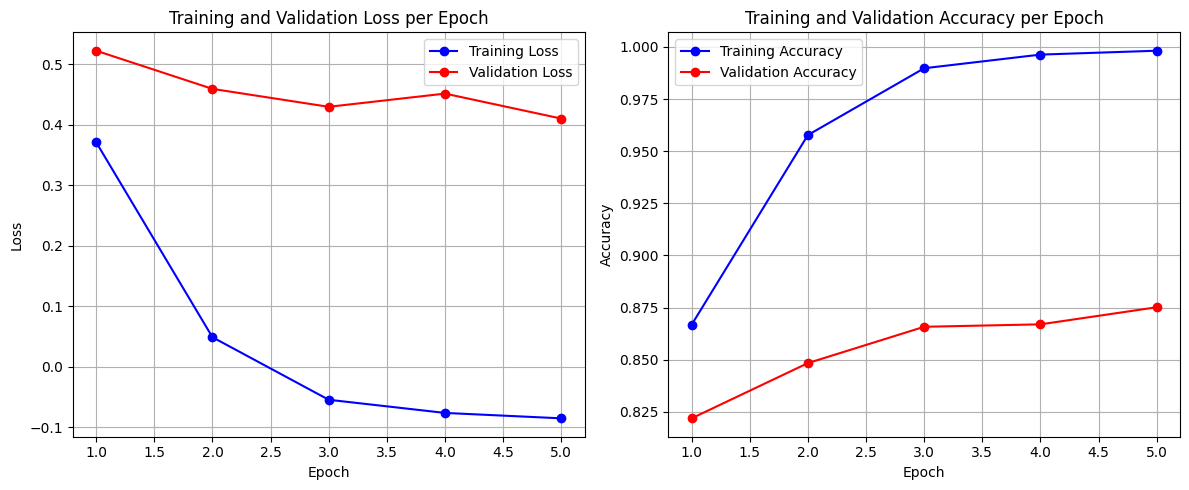

In [19]:
# Plot training history
import matplotlib.pyplot as plt

# Data
epochs = [1, 2, 3, 4, 5]
train_loss = [0.3707423426462472, 0.048613831366671, -0.05472208495175942, -0.07646572897778323, -0.08541343136670367]
val_loss = [0.5219862389299333, 0.4589312457330018, 0.42930320583498705, 0.4511350458489231, 0.4098537199959196]
train_acc = [0.8667454438031178, 0.9577330364041267, 0.9897741217106758, 0.9963186838158433, 0.998182066081898]
val_acc = [0.8218937509146788, 0.8483828479438021, 0.865798331625933, 0.8669691204448997, 0.8751646421776672]

plt.figure(figsize=(12, 5))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-o', label='Training Loss')
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'b-o', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-o', label='Validation Accuracy')
plt.title('Training and Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()